# Causal inference to understand student performance factors

## Overview
Dataset: student math performance measured in grades in secondary education of two Portuguese schools, available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/320/student+performance).

### Section 1: Data preparation


*   Aggregate grades from 3 different periods of a school year.
*   Combine features of high correlations.
*   Perform a random-forest-model-based feature selection. Use important features and their SHAP scores to narrow down to 11 variables for causal analysis.

### Section 2: DAG construction


*   Use PC and GES causal structure discovery algorithms from `causal-learn` to discover the DAG.
*   Combine output of structural discovery algorithm and pairwise chi-squared tests to draft the initial DAG for futher d-separation test.
*   Iteratively perform independence tests of d-separations using `pgmpy` module to identify discrepancies between the candidate models and the data. [Final DAG](#scrollTo=pACNOa3FIkzA&line=13&uniqifier=1)
*   Use `dowhy` `falsify_graph` function to refute the graph structure with permutation tests. [None of the permuations resulted in a better DAG that is consistent with the data.](#scrollTo=0ey8P3YaKYkX&line=1&uniqifier=1)


### Section 3: Parametric learning to construct structural causal model


*   `gcm` module automatically assigned stochastic or functional mechanisms to the nodes and picked the best `scikit-learn` model for predicting a non-root node with its parent nodes.
*   [Compare causal model with a gradient boosted regressor base model](#scrollTo=nDX9d9VgpDAK&line=2&uniqifier=1)
*   [Perform intervention simulation on students with past failures](#scrollTo=OWzIGEJ5qJDj&line=3&uniqifier=1)


### Section 4: Causal effect estimation and refutation


*   Calculate ATE and ATT of `higher` and `studytime` on `grade` using backdoor criterion.
*   Use multiple refuters to validate causal effect estimation: adding a random confounder, using a subset of data, or simulating placebo treatment.

Conclusion:
`higher` and `studytime` treatments would have significant impact on students’ grades if implemented.
This study demonstrated the generative and forecasting power of SCM that is not achievable correlation-based models.


In [ ]:
!pip install pgmpy dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
! pip install causallearn shap

ERROR: Could not find a version that satisfies the requirement causallearn (from versions: none)
ERROR: No matching distribution found for causallearn


In [ ]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pydot
import matplotlib.image as mpimg
import io
from pgmpy.base import DAG

## Section 1: Data preparation

### Exploratory data analysis and data processing

In [ ]:
sm = pd.read_csv('student_mat.csv', index_col=0)
sm.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
1,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
2,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
3,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
4,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
5,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
sm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher      649

In [ ]:
# drop age
sm.drop('age', axis=1, inplace=True)

In [ ]:
# sum g1, g2, g3
sm['grade'] = sm['G1'] + sm['G2'] + sm['G3']
sm.drop(['G1', 'G2', 'G3'], axis=1, inplace=True)

In [ ]:
num_vars = sm.select_dtypes(include=np.int64).columns

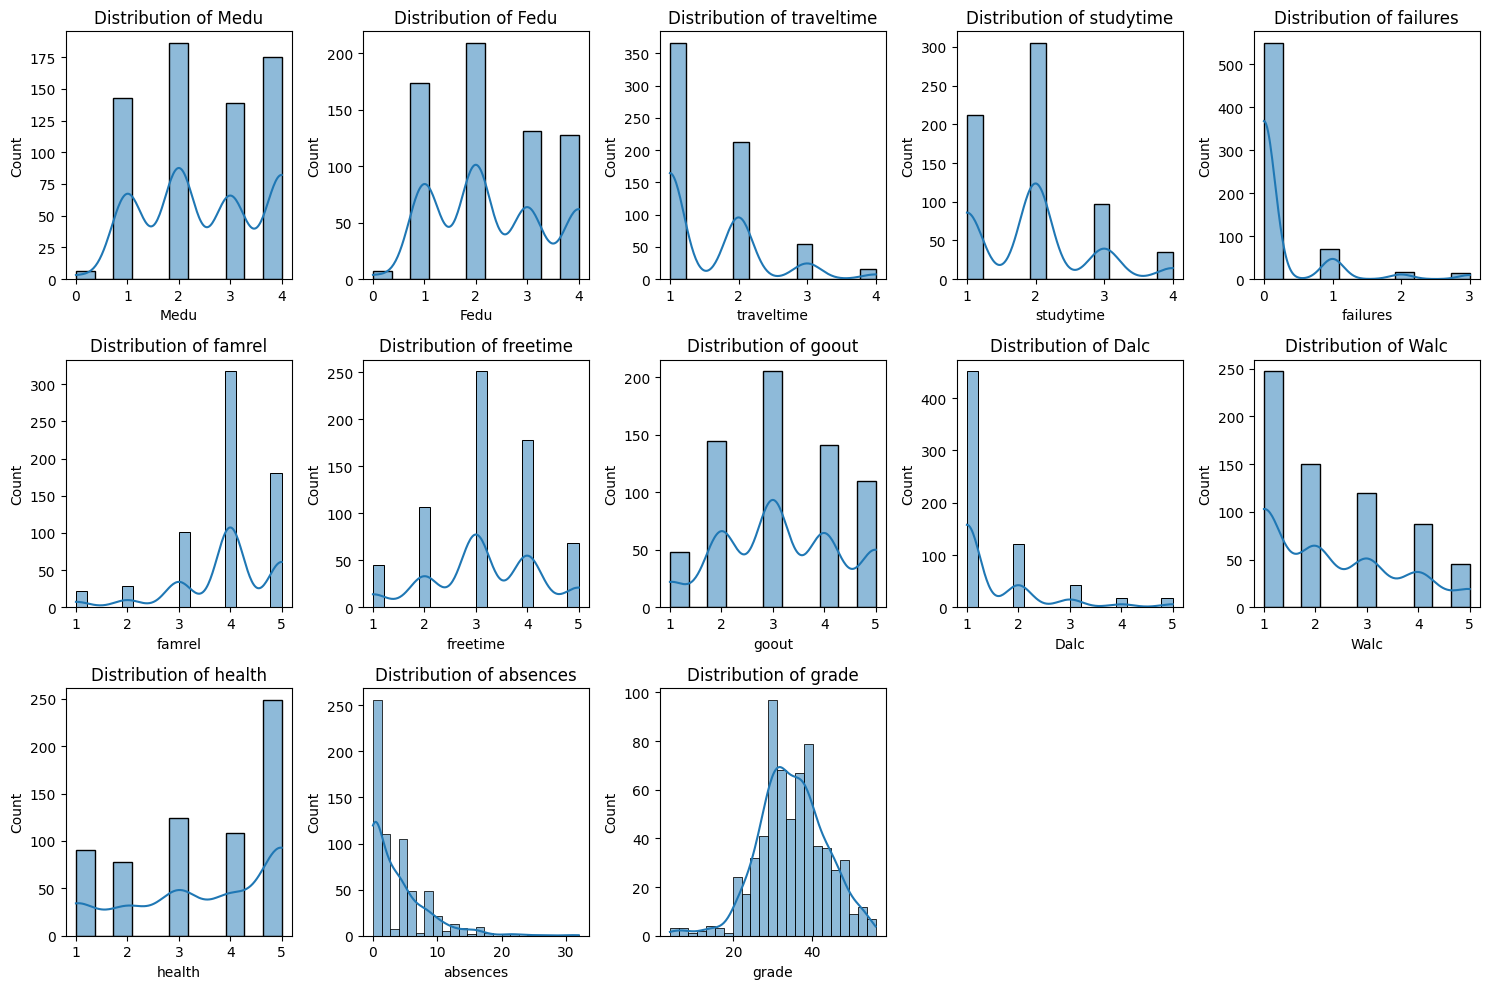

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars):
    plt.subplot(len(num_vars) // 5 + 1, 5, i + 1)
    sns.histplot(sm[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Variables')

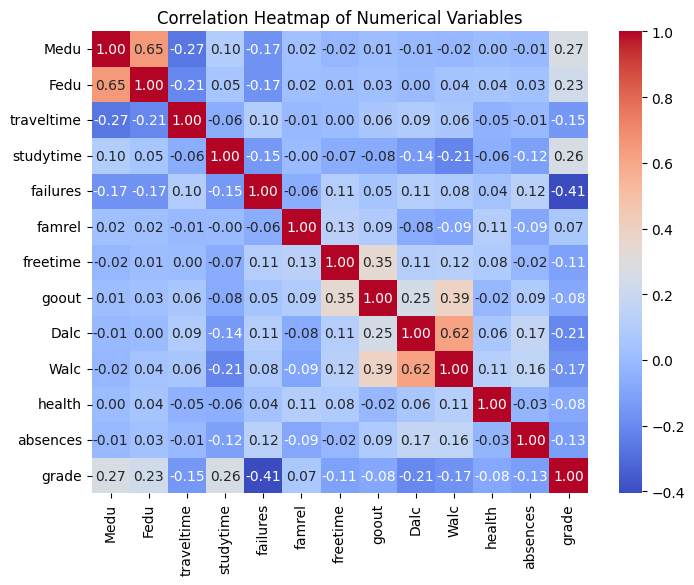

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(sm[num_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')

In [ ]:
sm['Pedu'] = sm['Fedu'] + sm['Medu']
sm['alc'] = sm['Dalc'] + sm['Walc']
sm.drop(['Fedu', 'Medu', 'Dalc', 'Walc'], axis=1, inplace=True)

In [ ]:
categorical_vars = sm.select_dtypes(include='object').columns

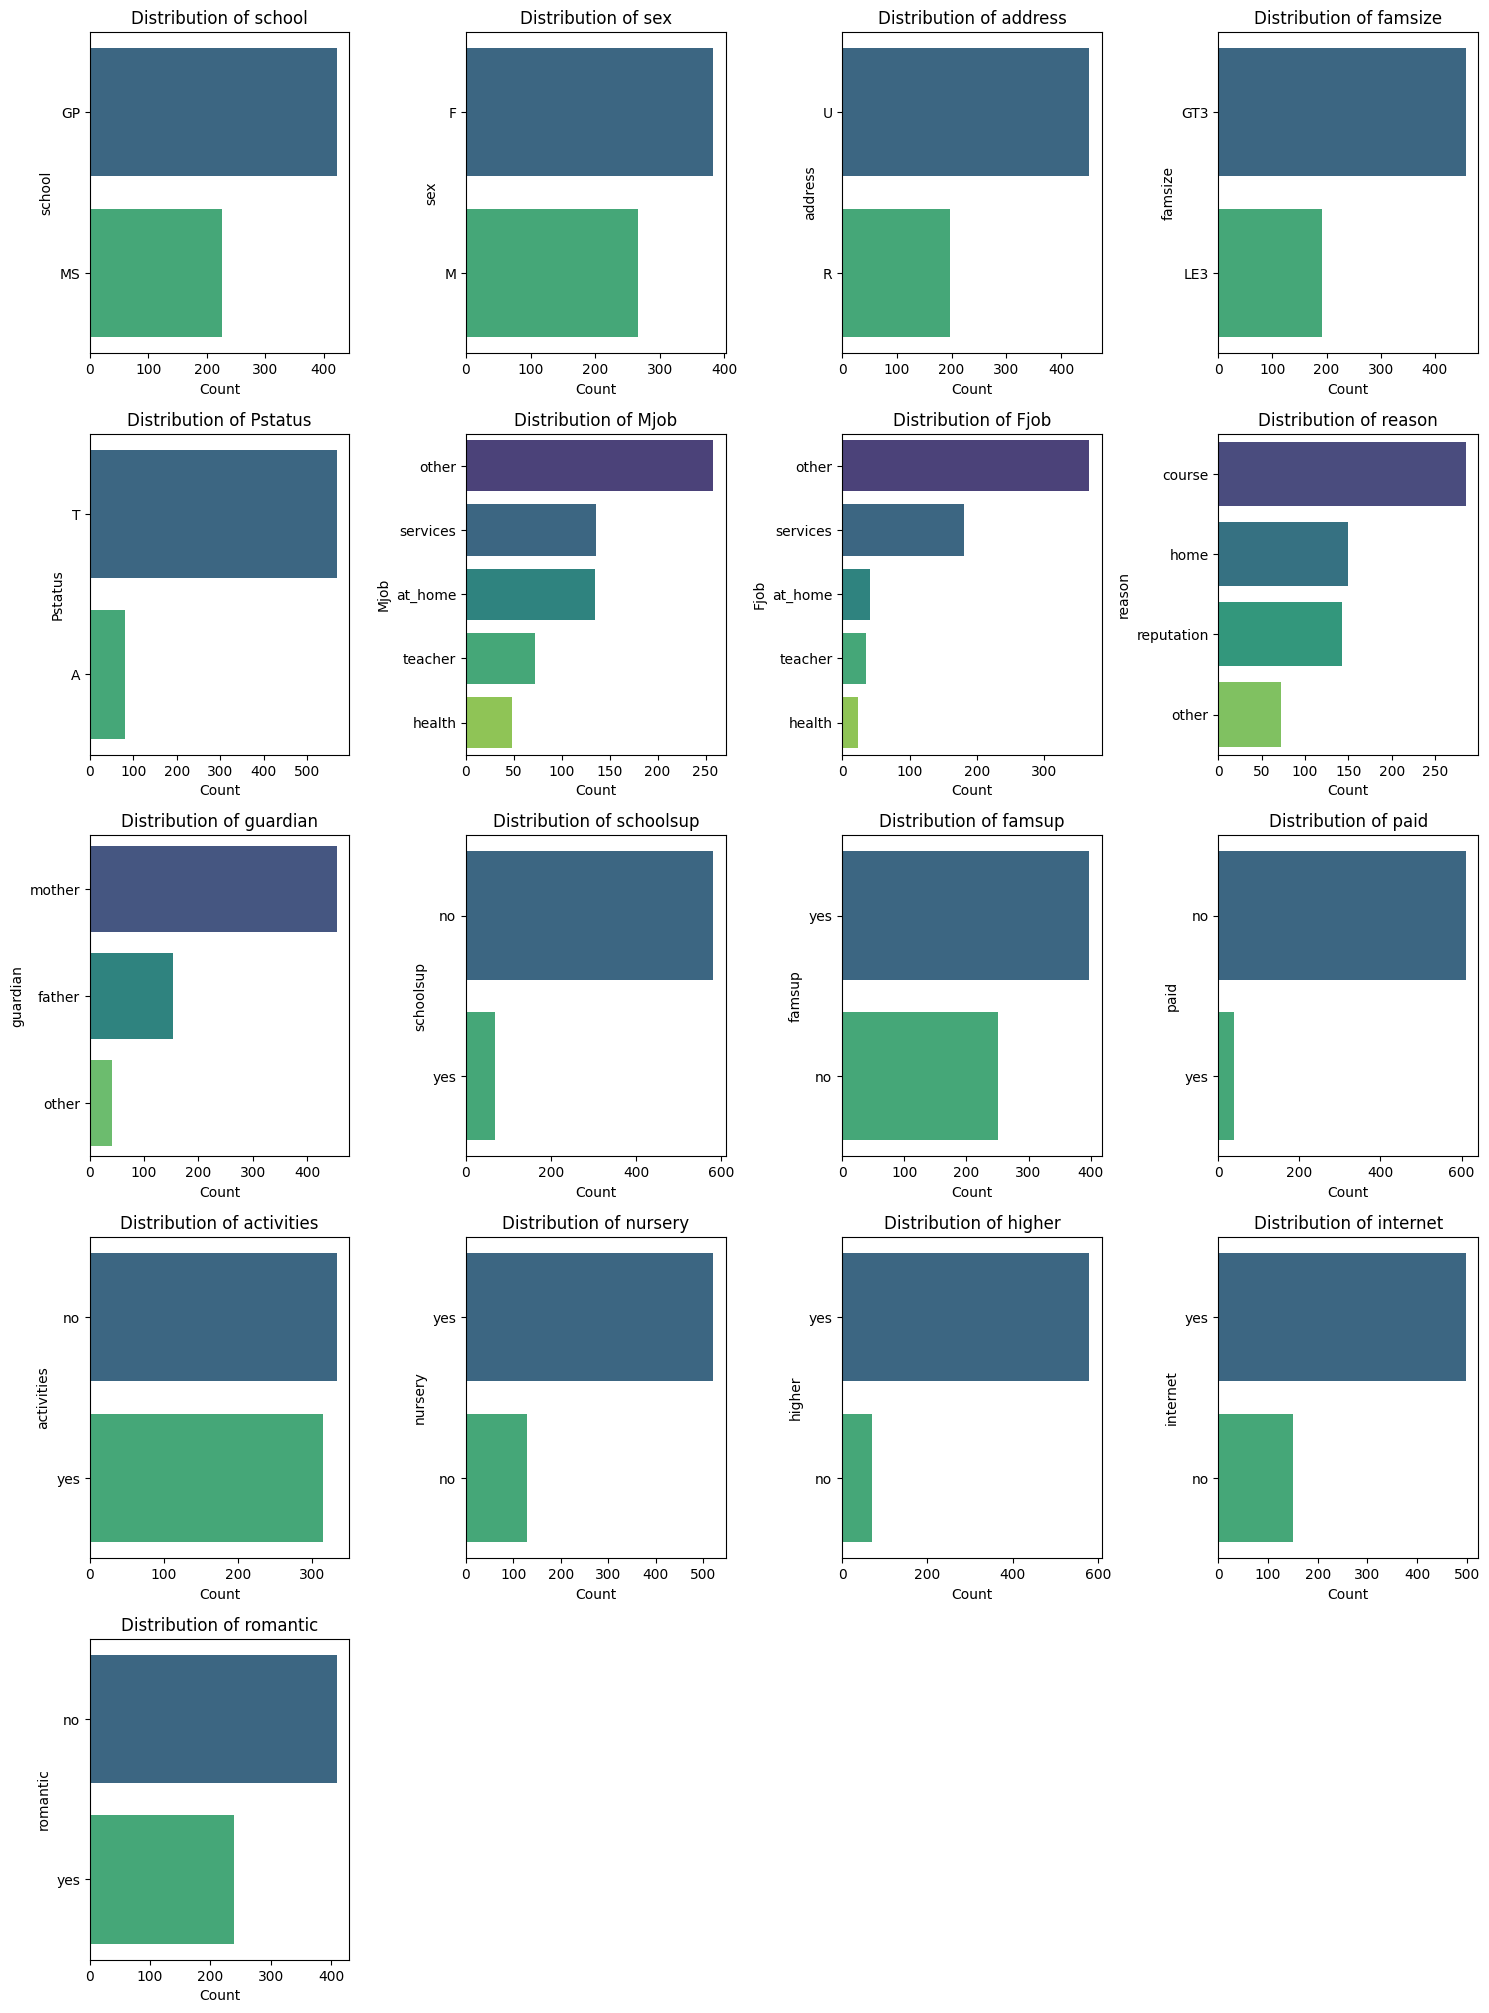

In [ ]:
plt.figure(figsize=(15, 4 * len(categorical_vars)))
for i, col in enumerate(categorical_vars):
    plt.subplot(len(categorical_vars), 4, i + 1)
    sns.countplot(y=sm[col], order=sm[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
len(sm.columns)

28

In [ ]:
sm_encoded = pd.get_dummies(sm, columns=categorical_vars, drop_first=True)

X = sm_encoded.drop('grade', axis=1)
y = sm_encoded['grade']

### Feature selection

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
feature_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("Top 10 Feature Importances from Random Forest Regressor:")
print(sorted_feature_importances.head(10))

Top 10 Feature Importances from Random Forest Regressor:
failures      0.201882
alc           0.072380
Pedu          0.062799
absences      0.057720
goout         0.046625
higher_yes    0.046623
studytime     0.043657
school_MS     0.039420
freetime      0.039201
health        0.038142
dtype: float64


In [ ]:
import shap
explainer = shap.TreeExplainer(rf_regressor)
shap_values = explainer.shap_values(X)

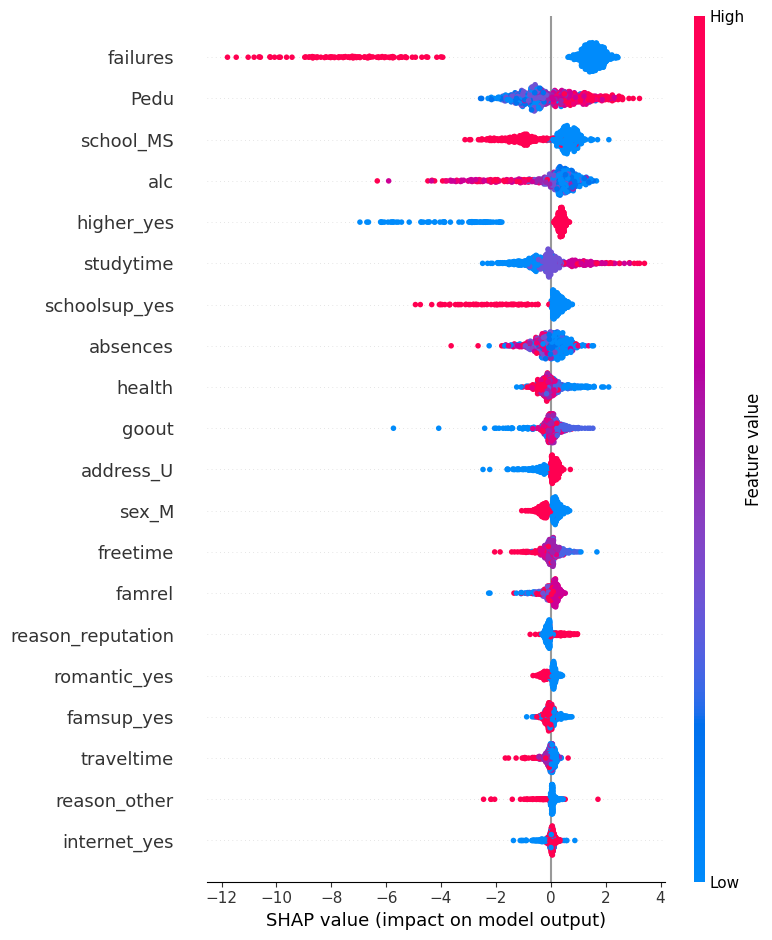

In [ ]:
shap.summary_plot(shap_values, X)

In [ ]:
top_features = ['failures', 'alc', 'Pedu', 'absences', 'higher',
       'studytime', 'school', 'schoolsup', 'address', 'sex']

In [ ]:
sm_top = sm[top_features]
sm_top['grade'] = sm['grade']

In [ ]:
cat_vars = sm_top.select_dtypes(include='object').columns
for col1, col2 in combinations(cat_vars, 2):
    print(f"\nCross-tabulation for {col1} and {col2}:")
    print(pd.crosstab(sm_top[col1], sm_top[col2]))

# address and school are dependent but not redundant


Cross-tabulation for higher and school:
school   GP   MS
higher          
no       32   37
yes     391  189

Cross-tabulation for higher and schoolsup:
schoolsup   no  yes
higher             
no          67    2
yes        514   66

Cross-tabulation for higher and address:
address    R    U
higher           
no        28   41
yes      169  411

Cross-tabulation for higher and sex:
sex       F    M
higher          
no       35   34
yes     348  232

Cross-tabulation for school and schoolsup:
schoolsup   no  yes
school             
GP         367   56
MS         214   12

Cross-tabulation for school and address:
address    R    U
school           
GP        78  345
MS       119  107

Cross-tabulation for school and sex:
sex       F    M
school          
GP      237  186
MS      146   80

Cross-tabulation for schoolsup and address:
address      R    U
schoolsup          
no         178  403
yes         19   49

Cross-tabulation for schoolsup and sex:
sex          F    M
schoolsup        

In [ ]:
sm_top.to_csv('sm_top.csv')

In [ ]:
sm_top.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   failures   649 non-null    int64  
 1   alc        649 non-null    float64
 2   Pedu       649 non-null    float64
 3   absences   649 non-null    int64  
 4   higher     649 non-null    object 
 5   studytime  649 non-null    int64  
 6   school     649 non-null    object 
 7   schoolsup  649 non-null    object 
 8   address    649 non-null    object 
 9   sex        649 non-null    object 
 10  grade      649 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 60.8+ KB


In [ ]:
lower_bound = sm_top['grade'].quantile(0.20)
upper_bound = sm_top['grade'].quantile(0.80)

bins = [sm_top['grade'].min() - 1, lower_bound, upper_bound, sm_top['grade'].max() + 1]
labels = ['low', 'mid', 'high']
sm_top['grade_group'] = pd.cut(sm_top['grade'], bins=bins, labels=labels, include_lowest=True, right=False)

In [ ]:
bins_abs = [0, 5, np.inf]
labels_abs = ['normal', 'high']
sm_top['absences_group'] = pd.cut(sm_top['absences'], bins=bins_abs, labels=labels_abs, include_lowest=True, right=False)

In [ ]:
sm_cat = sm_top.drop(['grade', 'absences'], axis=1)

## Section 2: DAG construction

### Structual discovery

  0%|          | 0/11 [00:00<?, ?it/s]

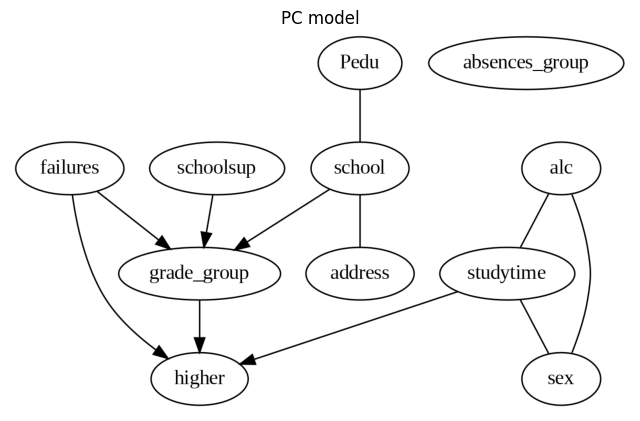

In [ ]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

cg = pc(sm_cat.to_numpy(), 0.05, chisq, node_names=sm_cat.columns.tolist())
plt.figure(figsize=(8, 6))
plt.title("PC model")
cg.draw_pydot_graph()

In [ ]:
# imposing some prior knowledge
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
bk = BackgroundKnowledge()
bk.add_forbidden_by_node(GraphNode('failures'), GraphNode('grade_group'))
bk.add_forbidden_by_node(GraphNode('grade_group'), GraphNode('failures'))
bk.add_required_by_node(GraphNode('higher'), GraphNode('grade_group'))
bk.add_required_by_node(GraphNode('higher'), GraphNode('studytime'))
bk.add_required_by_node(GraphNode('address'), GraphNode('school'))
bk.add_required_by_node(GraphNode('grade_group'), GraphNode('schoolsup'))

  0%|          | 0/11 [00:00<?, ?it/s]

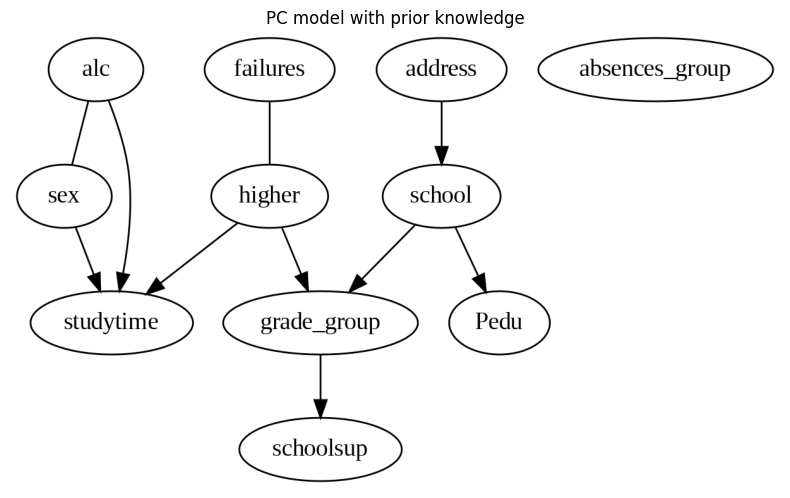

In [ ]:
cg = pc(sm_cat.to_numpy(), 0.05, chisq, node_names=sm_cat.columns.tolist(), background_knowledge=bk)
plt.figure(figsize=(8, 6))
plt.title("PC model with prior knowledge")
cg.draw_pydot_graph()

In [ ]:
# GES algorithm
from causallearn.search.ScoreBased.GES import ges
result = ges(sm_cat.to_numpy(), score_func='local_score_BDeu',
             node_names=sm_cat.columns.tolist())
cg_ges = result['G']

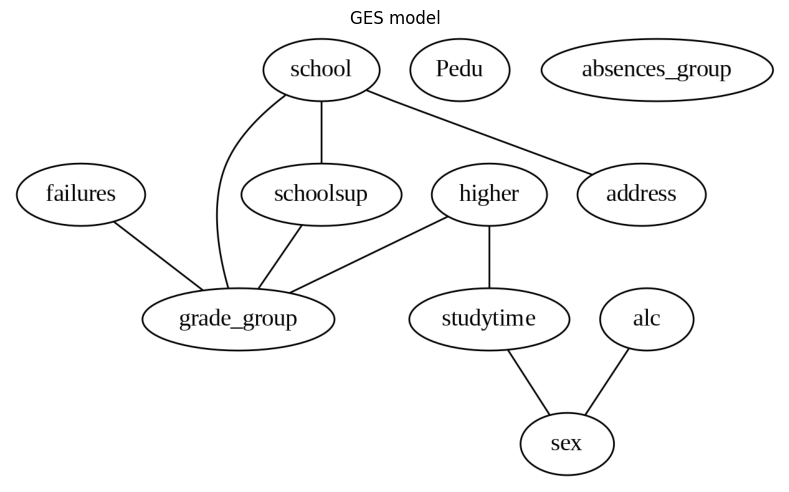

In [ ]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

pyd = GraphUtils.to_pydot(cg_ges)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.figure(figsize=(8, 6))
plt.axis('off')
plt.title("GES model")
plt.imshow(img)

### DAG construction through independence test

In [ ]:
from itertools import combinations
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance_level = 0.05

column_names = sm_cat.columns.tolist()

p_value_matrix = pd.DataFrame(1.0, index=column_names, columns=column_names)

for col1, col2 in combinations(column_names, 2):
    chi2_stat, p_value, dof = chi_square(
        X=col1, Y=col2, Z=[],
        data=sm_cat,
        boolean=False,
        significance_level=significance_level
    )
    p_value_matrix.loc[col1, col2] = p_value

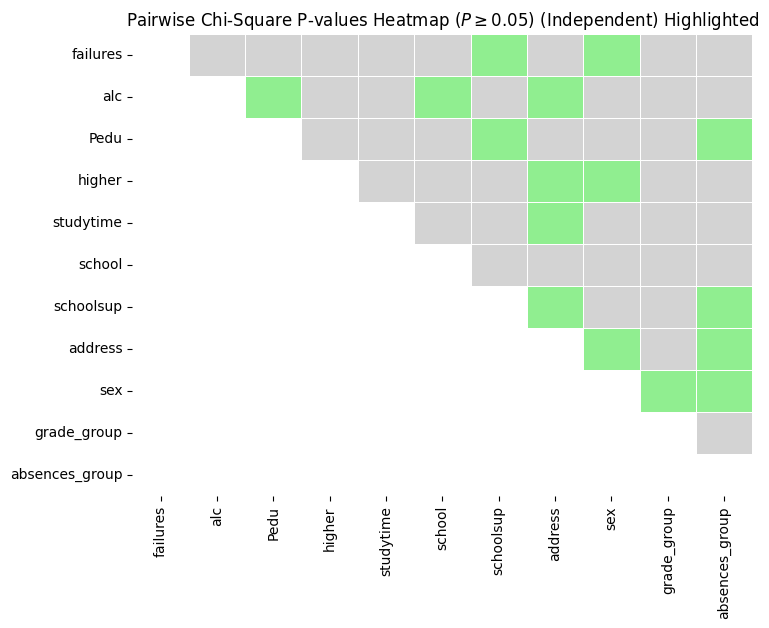

In [ ]:
import matplotlib.colors as mcolors

bounds = [p_value_matrix.min().min(), 0.05, p_value_matrix.max().max()]

colors = ['lightgray', 'lightgreen']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

mask = np.triu(np.ones_like(p_value_matrix, dtype=bool))
masked_p_value_matrix = p_value_matrix.mask(mask.transpose())

plt.figure(figsize=(8, 6))
sns.heatmap(masked_p_value_matrix, annot=False, cmap=cmap, fmt='.2e', linewidths=.5, cbar=False, norm=norm)
plt.title(r'Pairwise Chi-Square P-values Heatmap ($P \geq 0.05$ (Independent) Highlighted)')
plt.show()

The below DAG is an outcome of multiple rounds of modifications based on the independence tests. pgmpy version 0.1.24 also included too man d-separations that are not the minimal set of d-separations, which makes the inspection difficult. I used the newer version 1.0.0 for this set of analysis.

In [ ]:
# initial DAG
dag = DAG([('absences_group','school'),
           ('absences_group','alc'),
           ('sex','alc'),
           ('alc','studytime'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','studytime'),
           ('grade_group','schoolsup'),
           ('address','school'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures')])

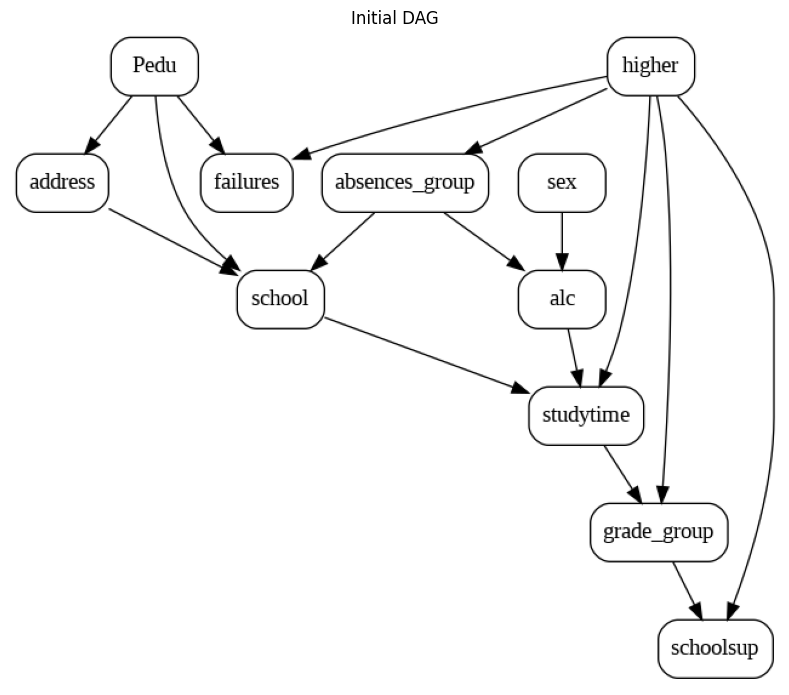

In [ ]:
dot = pydot.Dot(graph_type='digraph', rankdir='TB') # top-to-bottom

for node in dag.nodes():
    dot.add_node(pydot.Node(node, shape='box', style='rounded'))

for u, v in dag.edges():
    dot.add_edge(pydot.Edge(u, v))

tmp_png = dot.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.figure(figsize=(8, 8))
plt.axis('off')
plt.title("Initial DAG")
plt.imshow(img)

In [ ]:
# DAG after several rounds of modifications
dag = DAG([('absences_group','school'),
           ('absences_group','alc'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('alc','studytime'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','studytime'),
           ('grade_group','schoolsup'),
           ('address','school'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('failures','grade_group')])

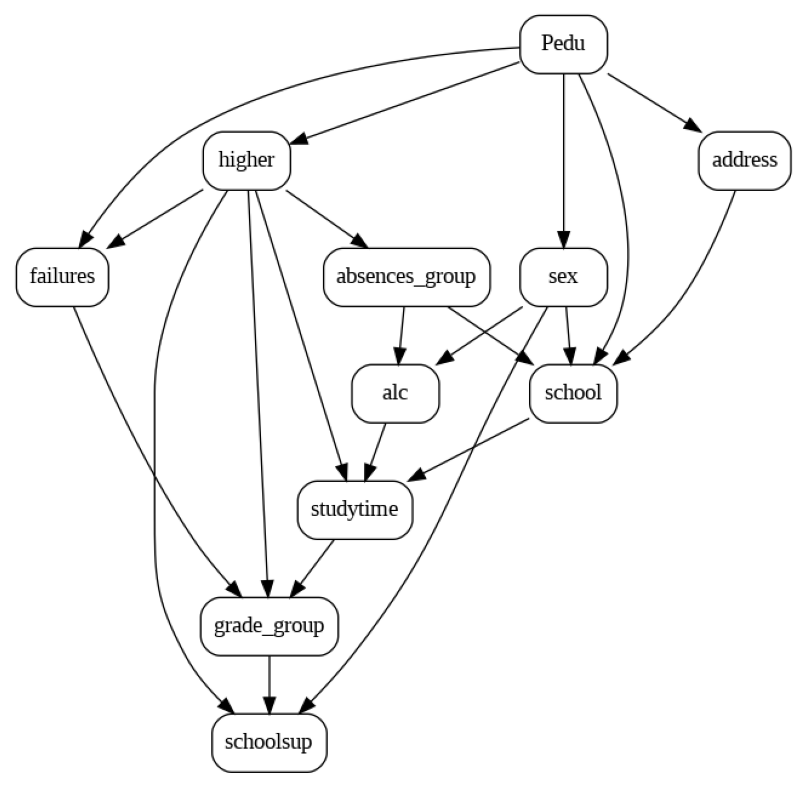

In [ ]:
dot = pydot.Dot(graph_type='digraph', rankdir='TB')

for node in dag.nodes():
    dot.add_node(pydot.Node(node, shape='box', style='rounded'))

for u, v in dag.edges():
    dot.add_edge(pydot.Edge(u, v))

tmp_png = dot.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.figure(figsize=(10, 8))
plt.axis('off')
plt.imshow(img)

In [ ]:
dseps = dag.get_independencies()

In [ ]:
significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=sm_cat,
                boolean=False
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

In [ ]:
results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
print("Assertions that are FALSE (i.e., data does NOT support independence):\n(p-value <= 0.05)")
false_results_filtered = {assertion: (value[0], value[1], value[2]) for assertion, value in results.items() if value[1] <= 0.05}
pprint(false_results_filtered)

Assertions that are FALSE (i.e., data does NOT support independence):
(p-value <= 0.05)
{(school ⟂ failures | absences_group, Pedu): (np.float64(54.21872526707991),
                                              np.float64(0.011392096763622184),
                                              33),
 (schoolsup ⟂ alc | higher, sex, grade_group): (np.float64(65.27643462808504),
                                                np.float64(0.012199801974798308),
                                                42),
 (school ⟂ grade_group | studytime, higher, Pedu): (np.float64(87.06218377462477),
                                                    np.float64(0.0006641832313883933),
                                                    49),
 (alc ⟂ failures | absences_group, Pedu): (np.float64(256.81670512311473),
                                           np.float64(0.0022960877474390573),
                                           196),
 (alc ⟂ higher | absences_group, Pedu): (np.float64(102.33798

In [ ]:
# failure-school dependence cannot be inferred from the data
dag = DAG([('absences_group','studytime'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('sex','studytime'),
           ('sex','failures'),
           ('alc','studytime'),
           ('alc','schoolsup'),
           ('alc','absences_group'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','grade_group'),
           ('school','studytime'),
           ('school','absences_group'),
           ('grade_group','schoolsup'),
           ('address','school'),
           ('address','absences_group'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('Pedu','alc'),
           ('Pedu','studytime'),
           ('failures','grade_group'),
           ('failures','alc'),
           ('failures','school')])

In [ ]:
dseps = dag.get_independencies()

In [ ]:
results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
print("Assertions that are FALSE (i.e., data does NOT support independence):\n(p-value <= 0.05)")
false_results_filtered = {assertion: (value[0], value[1], value[2]) for assertion, value in results.items() if value[1] <= 0.05}
pprint(false_results_filtered)

Assertions that are FALSE (i.e., data does NOT support independence):
(p-value <= 0.05)
{}


In [ ]:
# failure-school dependence cannot be inferred from the data
dag = DAG([('absences_group','studytime'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('sex','studytime'),
           ('sex','failures'),
           ('alc','studytime'),
           ('alc','schoolsup'),
           ('alc','absences_group'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','grade_group'),
           ('school','studytime'),
           ('school','absences_group'),
           ('school','failures'),
           ('grade_group','schoolsup'),
           ('address','school'),
           ('address','absences_group'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('Pedu','alc'),
           ('Pedu','studytime'),
           ('failures','grade_group'),
           ('failures','alc')])

In [ ]:
dseps = dag.get_independencies()

In [ ]:
results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
print("Assertions that are FALSE (i.e., data does NOT support independence):\n(p-value <= 0.05)")
false_results_filtered = {assertion: (value[0], value[1], value[2]) for assertion, value in results.items() if value[1] <= 0.05}
pprint(false_results_filtered)

Assertions that are FALSE (i.e., data does NOT support independence):
(p-value <= 0.05)
{}


Besides direct causal relationships, there could also be a unobserved confounder for the failure and school variables.

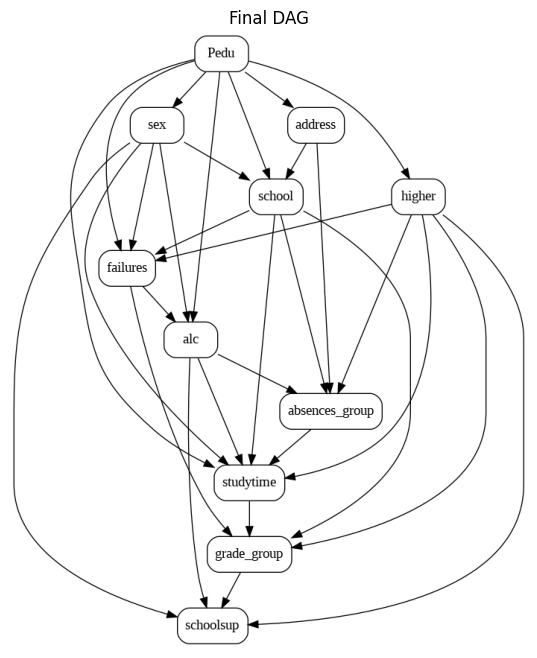

In [ ]:
# final model
dot = pydot.Dot(graph_type='digraph', rankdir='TB')

for node in dag.nodes():
    dot.add_node(pydot.Node(node, shape='box', style='rounded'))

for u, v in dag.edges():
    dot.add_edge(pydot.Edge(u, v))

tmp_png = dot.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')

plt.figure(figsize=(10, 8))
plt.title("Final DAG")
plt.axis('off')
plt.imshow(img)

## Section 3: Parametric learning to construct structural causal model

Further data cleaning

In [ ]:
# prepare data for structural causal model fitting
sm_gcm = sm_top.drop(['absences','grade_group'], axis=1)

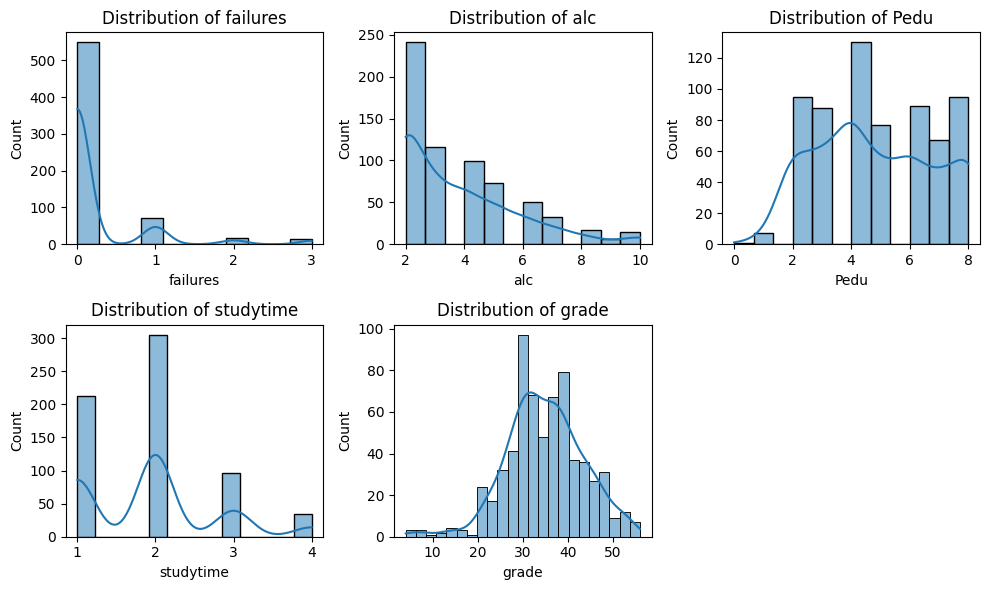

In [ ]:
num_vars = sm_gcm.select_dtypes(include=np.int64).columns
plt.figure(figsize=(10, 6))
for i, col in enumerate(num_vars):
    plt.subplot(len(num_vars) // 3 + 1, 3, i + 1)
    sns.histplot(sm_gcm[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# change negative binomial distributed variables to two levels
sm_gcm['alc'] = np.where(sm_gcm['alc'] > 5, 'high', 'low')
sm_gcm['failures'] = np.where(sm_gcm['failures'] > 0, 'yes', 'no')

In [ ]:
# group Pedu values
bins_Pedu = [0, 2, 4, 6, np.inf]
labels_Pedu = [1, 2, 3, 4]
sm_gcm['Pedu'] = pd.cut(sm_gcm['Pedu'], bins=bins_Pedu, labels=labels_Pedu, include_lowest=True, right=False).astype(np.int64)

In [ ]:
# prepare DAG to use original numeric variables in sm_gcm
dag_sf = DAG([('absences_group','studytime'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('sex','studytime'),
           ('sex','failures'),
           ('alc','studytime'),
           ('alc','schoolsup'),
           ('alc','absences_group'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade'),
           ('higher','grade'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','grade'),
           ('school','studytime'),
           ('school','absences_group'),
           ('school','failures'),
           ('grade','schoolsup'),
           ('address','school'),
           ('address','absences_group'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('Pedu','alc'),
           ('Pedu','studytime'),
           ('failures','grade'),
           ('failures','alc')])

In [ ]:
# prepare DAG to use original numeric variables in sm_gcm
dag_fs = DAG([('absences_group','studytime'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('sex','studytime'),
           ('sex','failures'),
           ('alc','studytime'),
           ('alc','schoolsup'),
           ('alc','absences_group'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade'),
           ('higher','grade'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','grade'),
           ('school','studytime'),
           ('school','absences_group'),
           ('school','failures'),
           ('grade','schoolsup'),
           ('address','school'),
           ('address','absences_group'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('Pedu','alc'),
           ('Pedu','studytime'),
           ('failures','grade'),
           ('failures','alc')])

Refute graph model with `dowhy` `falsify_graph` function.

In [ ]:
from dowhy.gcm.falsify import falsify_graph


Test permutations of given graph: 100%|██████████| 20/20 [04:42<00:00, 14.15s/it]


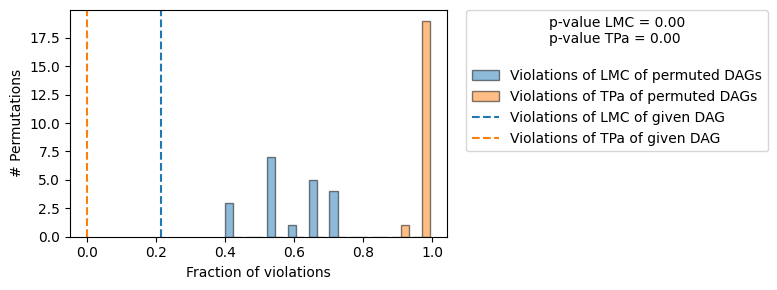

In [ ]:
result = falsify_graph(dag_sf, sm_gcm, plot_histogram=True,suggestions=True)

In [ ]:
print(result)

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/28 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+
|                                             

Test permutations of given graph: 100%|██████████| 20/20 [03:57<00:00, 11.85s/it]


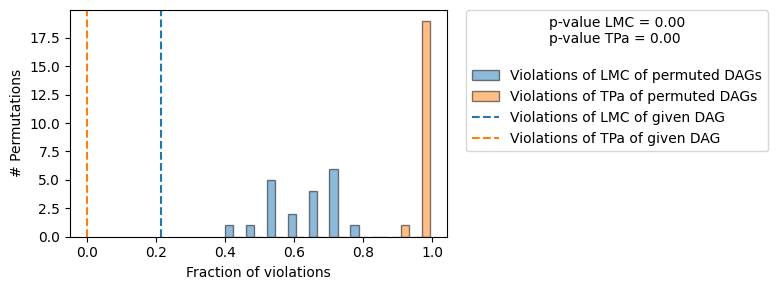

In [ ]:
result_fs = falsify_graph(dag_fs, sm_gcm, plot_histogram=True,suggestions=True)

In [ ]:
print(result_fs)

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/28 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+
|                                             

Causal structure evaluation:

*   Local Markov conditions (LMC) is tested by running conditional independence tests: $X_i \perp \!\!\! \perp X_j \in \text{NonDesc}_{X_i} \ | \ \text{PA}_{X_i}$. Randomly permutated graphs were compared to the given DAG. p-value means the probability of a random node permutation (the null) having as few or fewer violations as the given DAG.
*   tPA evaluate which pairwise parental d-separations (parental triples) in given DAG are violated after permuation: $X \perp_{G'} Y \mid Z \quad \text{and} \quad X \not\perp_{G} Y \mid Z \quad \text{for} \quad Y \in \text{ND}(X)^{G'}, Z = \text{PA}(X)^{G}$. It counts the number of permuted DAGs lying in the same Markov equivalent class (MEC) as the given DAG. low p-value means that few permutations lie in the same MEC and the independences entailed by the given DAG are characteristic in the sense that the given DAG is falsifiable by testing implied CIs.

For the two Markov equivalent graphs, `dag_sf` and `dag_fs`, neither was rejected through permutation comparisons. I also tested all the suggestions of modification using `pgmpy`, the independence induced by removing the suggested edges were all rejected.

### Constructing Structural Causal Model

In [ ]:
from dowhy import gcm
causal_model = gcm.InvertibleStructuralCausalModel(dag_sf)

In [ ]:
summary_mechanism = gcm.auto.assign_causal_mechanisms(causal_model, sm_gcm)

In [ ]:
print(summary_mechanism)

When using this auto assignment function, the given data is used to automatically assign a causal mechanism to each node. Note that causal mechanisms can also be customized and assigned manually.
The following types of causal mechanisms are considered for the automatic selection:

If root node:
An empirical distribution, i.e., the distribution is represented by randomly sampling from the provided data. This provides a flexible and non-parametric way to model the marginal distribution and is valid for all types of data modalities.

If non-root node and the data is continuous:
Additive Noise Models (ANM) of the form X_i = f(PA_i) + N_i, where PA_i are the parents of X_i and the unobserved noise N_i is assumed to be independent of PA_i.To select the best model for f, different regression models are evaluated and the model with the smallest mean squared error is selected.Note that minimizing the mean squared error here is equivalent to selecting the best choice of an ANM.

If non-root node

In [ ]:
gcm.fit(causal_model, sm_gcm)

Fitting causal mechanism of node Pedu: 100%|██████████| 11/11 [00:00<00:00, 20.38it/s]


Causal mechanism evaluation show good prediction outcome (low CRPS score) for all categorical variables, while the models for the numeric variables only had fair performance.
The additive noise model assumption is false for `studytime`.





In [ ]:
print(gcm.evaluate_causal_model(causal_model, sm_gcm, evaluate_causal_mechanisms=True, evaluate_causal_structure=False,
                                evaluate_invertibility_assumptions=True, compare_mechanism_baselines=True))

Evaluating causal mechanisms...: 100%|██████████| 11/11 [02:29<00:00, 13.63s/it]


Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the underlying classifier model.


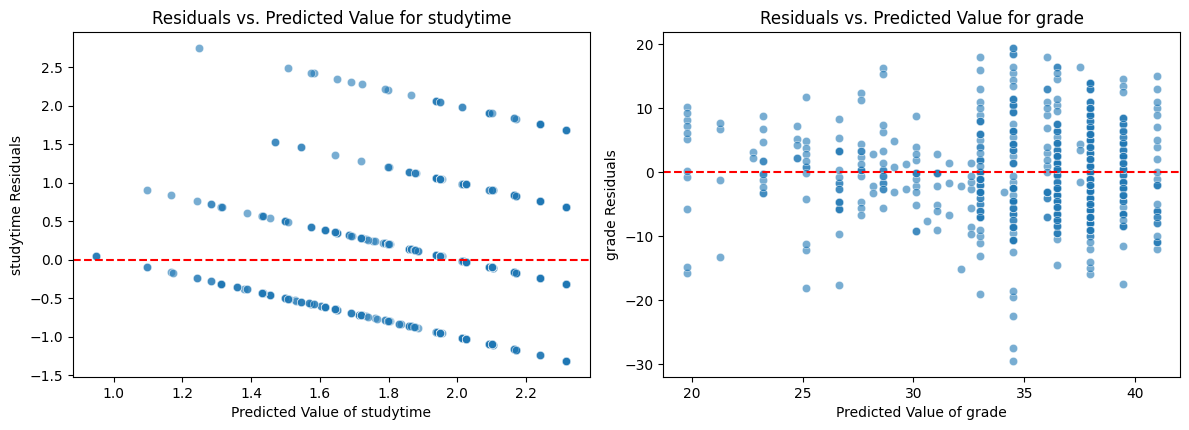

In [ ]:
# check the residual
num_node = ['studytime', 'grade']

plt.figure(figsize=(12, 8))

for i, node in enumerate(num_node):
    mechanism = causal_model.causal_mechanism(node)
    parents = list(causal_model.graph.predecessors(node))

    obs = sm_gcm[node]

    parent_data = sm_gcm[parents].to_numpy()
    mechanism.prediction_model.fit(parent_data, obs.to_numpy())
    pred = mechanism.prediction_model.predict(parent_data)
    pred = pred.flatten()

    residuals = obs - pred

    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=pred, y=residuals, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residuals vs. Predicted Value for {node}')
    plt.xlabel(f'Predicted Value of {node}')
    plt.ylabel(f'{node} Residuals')

plt.tight_layout()
plt.show()

Tested some other parameters for fitting `studytime` and `grade`. Specifying sample_weight in fit() has better prediction range. However, it is not straightforward to train each mechanism separately and embed it in causal_model. It seems to reorder the column sequences of the sliced data and runs into errors.

In [ ]:
mechanism = causal_model.causal_mechanism('studytime')
parents = list(causal_model.graph.predecessors('studytime'))
X = pd.get_dummies(sm_gcm[parents]).to_numpy()
y = sm_gcm['studytime']

In [ ]:
parents

['absences_group', 'sex', 'alc', 'higher', 'school', 'Pedu']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
alpha = 0.3
smoothed_weights = alpha * sample_weights + (1 - alpha) * np.mean(sample_weights)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor()
hgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = hgb.predict(X)

Text(0, 0.5, 'Predicted Value of studytime')

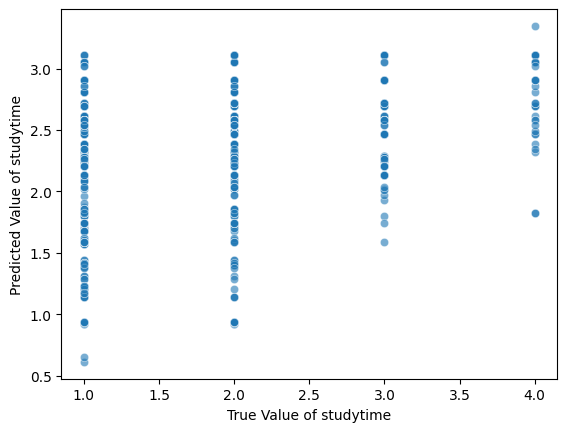

In [ ]:
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.xlabel(f'True Value of studytime')
plt.ylabel(f'Predicted Value of studytime')

In [ ]:
mechanism = causal_model.causal_mechanism('grade')
parents = list(causal_model.graph.predecessors('grade'))
X = sm_gcm[parents]
y = sm_gcm['grade']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in X.select_dtypes(exclude=['int64']).columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
min_grade = y.min()
max_grade = 60
cutoff = 20
bins_edges = [min_grade - 0.001]
bins_edges.append(cutoff)

if max_grade >= cutoff:
    upper_bins_linspace_points = np.linspace(cutoff, max_grade + 0.001, 5 + 1)
    bins_edges.extend(upper_bins_linspace_points[1:])
bins = np.unique(bins_edges)

y_binned = pd.cut(y, bins=bins, labels=False, include_lowest=True, right=False)

print(f"Value counts for bins:\n{y_binned.value_counts().sort_index()}")

Value counts for bins:
grade
0     17
1    114
2    242
3    190
4     74
5     12
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_binned)

y_train_binned = y_binned.loc[y_train.index]

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_binned)
alpha = 0.1
smoothed_weights = alpha * sample_weights + (1 - alpha) * np.mean(sample_weights)

<Axes: xlabel='grade'>

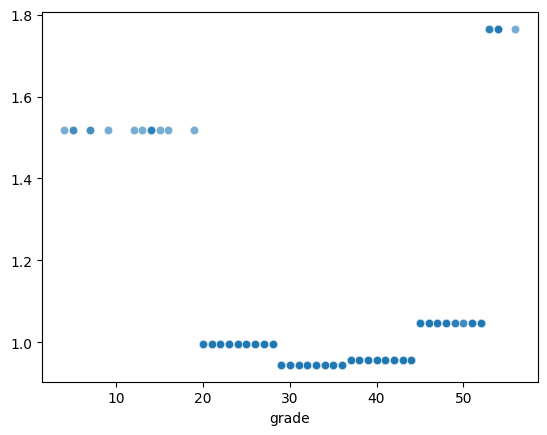

In [ ]:
sns.scatterplot(x=y_train, y=smoothed_weights, alpha=0.6)

In [ ]:
from sklearn.linear_model import LinearRegression
lg = LinearRegression()
lg.fit(X_train, y_train, sample_weight=smoothed_weights)

y_pred = lg.predict(X)

Text(0, 0.5, 'Residuals')

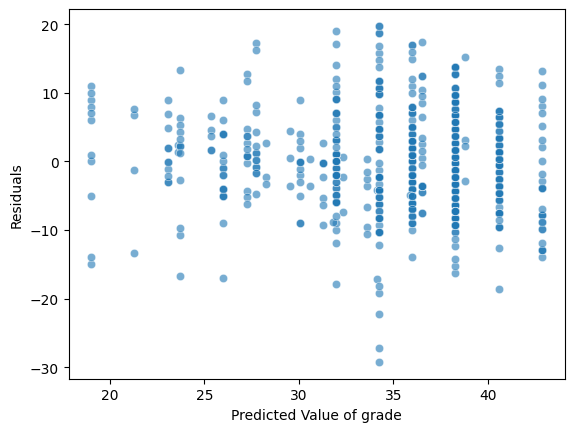

In [ ]:
sns.scatterplot(x=y_pred, y=y-y_pred, alpha=0.6)
plt.xlabel(f'Predicted Value of grade')
plt.ylabel(f'Residuals')

### Compare causal model predictions and a gradient boost regression baseline

Gradient boost regressor as baseline.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
sm_int = sm_gcm.copy()
categorical_cols = sm_int.select_dtypes(exclude=['int64']).columns
for col in categorical_cols:
    sm_int[col] = le.fit_transform(sm_int[col])

sm_int.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   failures        649 non-null    int64
 1   alc             649 non-null    int64
 2   Pedu            649 non-null    int64
 3   higher          649 non-null    int64
 4   studytime       649 non-null    int64
 5   school          649 non-null    int64
 6   schoolsup       649 non-null    int64
 7   address         649 non-null    int64
 8   sex             649 non-null    int64
 9   grade           649 non-null    int64
 10  absences_group  649 non-null    int64
dtypes: int64(11)
memory usage: 60.8 KB


In [ ]:
X=sm_int.drop('grade', axis=1)
y=sm_int['grade']

In [ ]:
# without splitting to compare between prediction and generative models
from sklearn.model_selection import train_test_split

lower_bound = y.quantile(0.20)
upper_bound = y.quantile(0.80)
bins = [y.min() - 1, lower_bound, upper_bound, y.max() + 1]
labels = ['low', 'mid', 'high']
grade_group = pd.cut(y, bins=bins, labels=labels, include_lowest=True, right=False)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=grade_group)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X, y)
gb_predictions = gb_regressor.predict(X)

In [ ]:
mse_gb = mean_squared_error(y, gb_predictions)
print("Gradient Boosting MSE:", mse_gb)

Gradient Boosting MSE: 39.395238043059955


The mse of GB regressor is lower than the submodel in the structural causal model, which only regressed with 4 variables that are direct parents of `grade`: `failures`,`higher`,`school`,`studytime`.

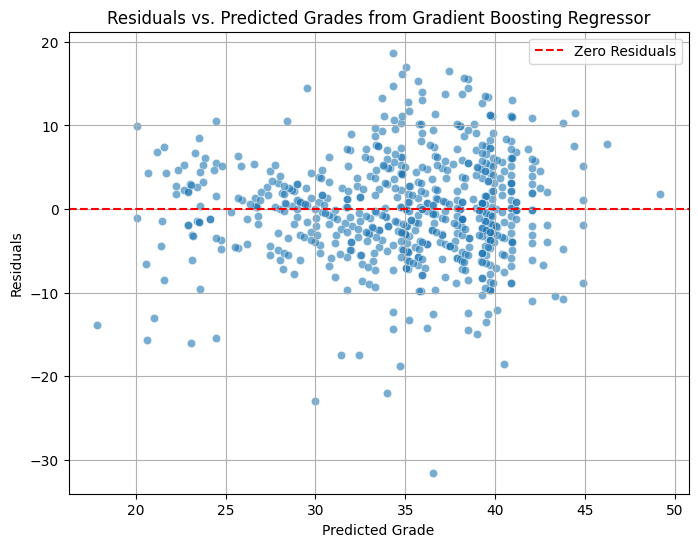

In [ ]:
residuals = y - gb_predictions

plt.figure(figsize=(8, 6))
sns.scatterplot(x=gb_predictions, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residuals')
plt.xlabel('Predicted Grade')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Grades from Gradient Boosting Regressor')
plt.grid(True)
plt.legend()
plt.show()

Compare the distribution of the prediction, causal-model-generated data and the true grades.

In [ ]:
generated_data = gcm.draw_samples(causal_model, num_samples=len(y))

In [ ]:
def discretize_probability(data):
    bins = np.linspace(min(data.min(), data.min()), 100)
    hist, _ = np.histogram(data, bins=bins, density=True)
    eps = 1e-10
    hist += eps
    probs = hist / np.sum(hist)
    return probs

In [ ]:
prob_y = discretize_probability(y)
prob_gb = discretize_probability(gb_predictions)
prob_gcm = discretize_probability(generated_data['grade'])

from scipy.stats import entropy
KL_gb = entropy(prob_y, prob_gb)
KL_gcm = entropy(prob_y, prob_gcm)

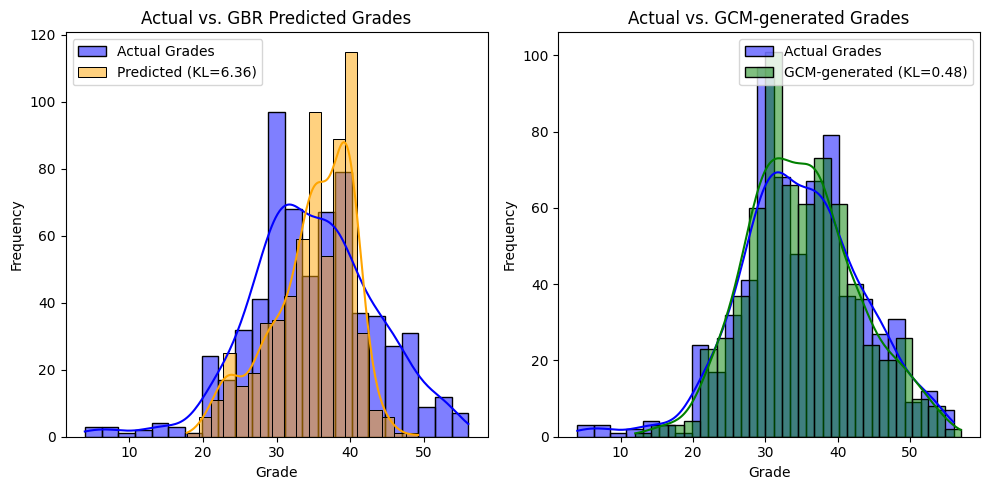

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, label='Actual Grades', color='blue')
sns.histplot(gb_predictions, kde=True, label=f'Predicted (KL={KL_gb:.2f})', color='orange')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.title('Actual vs. GBR Predicted Grades')
plt.legend()

plt.subplot(1, 2, 2)
sns.histplot(y, kde=True, label='Actual Grades', color='blue')
sns.histplot(generated_data['grade'], kde=True, label=f'GCM-generated (KL={KL_gcm:.2f})', color='green')
plt.xlabel('Grade')
plt.ylabel('Frequency')
plt.title('Actual vs. GCM-generated Grades')
plt.legend()

plt.tight_layout()
plt.show()

### Counterfactual analysis

This is easy to do with an invertible structural  model inplace. All needed is plugging in the varibles and use observational data to estimate individual noise. However, dowhy does not yet support estimation of noise for functional structural model with categorical variable. I did intervention simulations instead.   
Another option is using normalizing flow.

In [ ]:
cf_samples = gcm.counterfactual_samples(causal_model,
                                        {'studytime': lambda x: x+2},
                                        observed_data=sm_gcm[sm_gcm['failures'] == 'yes'])

AttributeError: 'ClassifierFCM' object has no attribute 'estimate_noise'

### Interventional simulations

In [ ]:
def draw_intervention(original_data, interventional_data, title):
    sns.kdeplot(original_data, color='blue', label='Original Data')
    sns.kdeplot(interventional_data, color='red', label='Interventional Data')
    plt.axvline(x=original_data.mean(), color='blue', linestyle='--', label='Original Mean')
    plt.axvline(x=interventional_data.mean(), color='red', linestyle='--', label='Interventional Mean')
    plt.xlabel('Grade')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.legend()
    plt.show()

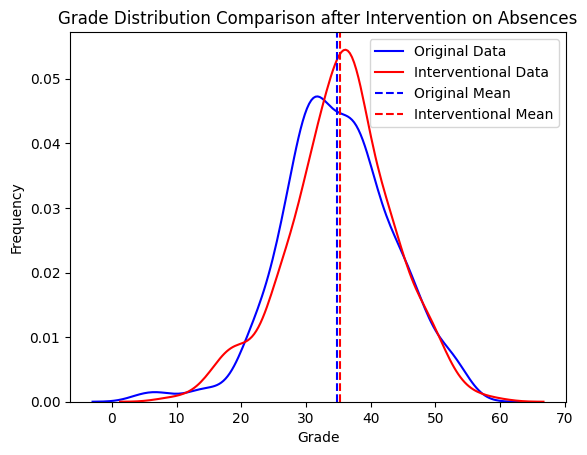

In [ ]:
# intervention on the whole population
samples = gcm.interventional_samples(causal_model,
                                     {'absences_group': lambda x: 'normal'},
                                     num_samples_to_draw=len(sm_gcm))

draw_intervention(sm_gcm['grade'], samples['grade'], 'Grade Distribution Comparison after Intervention on Absences')

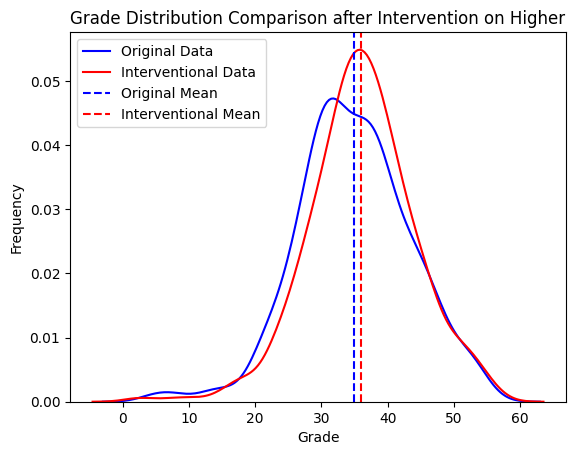

In [ ]:
# intervention on the whole population. Here the effect of intervention is not as high as the estimated causal effect using backdoor estimand.
# This is due to low level of higher=0 in the population. Changing their grades by do(higher=1) had littel effect on the population average.
samples = gcm.interventional_samples(causal_model,
                                     {'higher': lambda x: 'yes'},
                                     num_samples_to_draw=len(sm_gcm))
draw_intervention(sm_gcm['grade'], samples['grade'], 'Grade Distribution Comparison after Intervention on Higher')

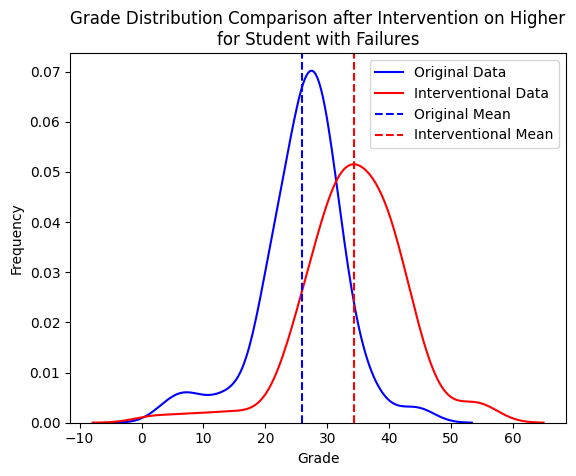

In [ ]:
samples = gcm.interventional_samples(causal_model,
                                     {'higher': lambda x: 'yes',
                                      'failures': lambda x: x},
                                     observed_data=sm_gcm[sm_gcm['failures'] =='yes'])
draw_intervention(sm_gcm[sm_gcm['failures'] =='yes']['grade'], samples['grade'],
                  'Grade Distribution Comparison after Intervention on Higher\nfor Student with Failures')

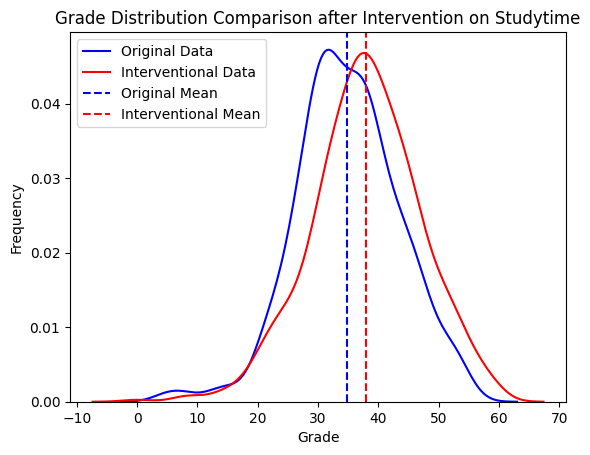

In [ ]:
samples = gcm.interventional_samples(causal_model,
                                     {'studytime': lambda x: x + 2},
                                     num_samples_to_draw=len(sm_gcm))
draw_intervention(sm_gcm['grade'], samples['grade'], 'Grade Distribution Comparison after Intervention on Studytime')

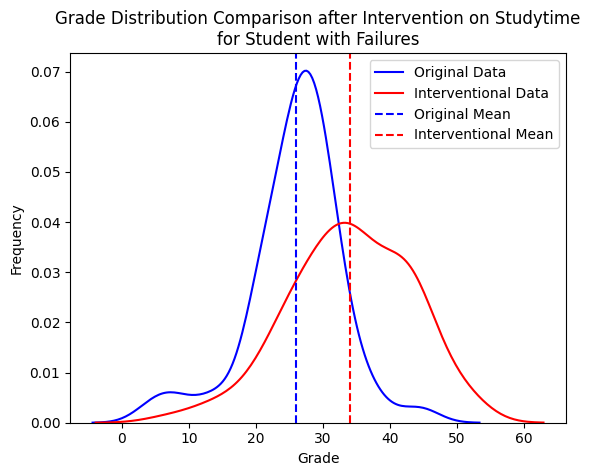

In [ ]:
samples = gcm.interventional_samples(causal_model,
                                     {'studytime': lambda x: x + 2,
                                      'failures': lambda x: x},
                                     observed_data=sm_gcm[sm_gcm['failures'] =='yes'])
draw_intervention(sm_gcm[sm_gcm['failures'] =='yes']['grade'], samples['grade'],
                  'Grade Distribution Comparison after Intervention on Studytime\nfor Student with Failures')

In [ ]:
# combined effect of higher, studytime
samples = gcm.interventional_samples(causal_model,
                                     {'studytime': lambda x: x + 2,
                                      'higher': lambda x: 'yes',
                                      'failures': lambda x: x},
                                     observed_data=sm_gcm[sm_gcm['failures'] =='yes'])

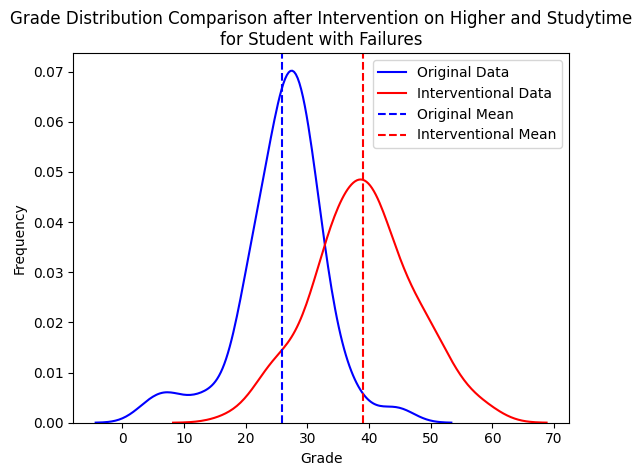

In [ ]:
draw_intervention(sm_gcm[sm_gcm['failures'] =='yes']['grade'], samples['grade'],
                  'Grade Distribution Comparison after Intervention on Higher and Studytime\nfor Student with Failures')

## Section 4: Causal effect estimation and refutation

### Calculate causal effect

`dowhy` can also directly perform do operations on the graphic causal model. Under the hood, it used different methods to identify the appropriate control groups from the observational data to compare with similar cases but receiving a particular treatment.

In [ ]:
le = LabelEncoder()
sm_int = sm_gcm.copy()
categorical_cols = sm_int.select_dtypes(exclude=['int64']).columns
for col in categorical_cols:
    sm_int[col] = le.fit_transform(sm_int[col])

sm_int.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   failures        649 non-null    int64
 1   alc             649 non-null    int64
 2   Pedu            649 non-null    int64
 3   higher          649 non-null    int64
 4   studytime       649 non-null    int64
 5   school          649 non-null    int64
 6   schoolsup       649 non-null    int64
 7   address         649 non-null    int64
 8   sex             649 non-null    int64
 9   grade           649 non-null    int64
 10  absences_group  649 non-null    int64
dtypes: int64(11)
memory usage: 60.8 KB


In [ ]:
from dowhy import CausalModel

In [ ]:
model=CausalModel(
        data = sm_int,
        treatment="higher",
        outcome="grade",
        graph=dag_sf
        )

In [ ]:
estimand_hi = model.identify_effect(proceed_when_unidentifiable=True)
print(estimand_hi)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)



The treatment `higher` is binary. The available estimators for binary treatment in `dowhy` are:


*   Propensity-Based Estimators: `backdoor.propensity_score_stratification`,`backdoor.propensity_score_weighting`,`backdoor.propensity_score_matching`
*   Distance Matching Estimators: `backdoor.distance_matching`
*   Regression & Model-Based Estimators: `backdoor.linear_regression`, `backdoor.generalized_linear_model`

`propensity_score_stratification_estimator` estimates effect of treatment by stratifying the data into bins with identical common causes (Z). A propensity score is calculated for each cases as the probability of receiving the treatment predicted by Z. Within each strata, the treatment assignment is independent of the potential outcomes, effectively simulating a mini-randomized controlled trial. The final Average Treatment Effect (ATE) is calculated by taking a weighted average of the effects across all strata.

In [ ]:
estimate_hi_ps = model.estimate_effect(estimand_hi, confidence_intervals=True,
        method_name="backdoor.propensity_score_stratification")
print(estimate_hi_ps)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)

## Realized estimand
b: grade~higher+Pedu
Target units: ate

## Estimate
Mean value: 8.337144601430314
95.0% confidence interval: (np.float64(6.161123772009594), np.float64(10.027042685706519))



The `distance_matching_estimator` uses distance metrics to identify the nearest neighbor without the treatment for each individual receiving the treatment (1-to-1 matching), or match to the average of k nearest neighbors.

In [ ]:
estimate_hi_dmatch = model.estimate_effect(estimand_hi,
                                           method_name="backdoor.distance_matching",
                                           confidence_intervals=True,
                                           target_units="ate",
                                           method_params={'distance_metric':"minkowski", 'p':2,
                                                          'num_matches_per_unit':1}) # 1 is default
print(estimate_hi_dmatch)
print("Causal Estimate is " + str(estimate_hi_dmatch.value))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)

## Realized estimand
b: grade~higher+Pedu
Target units: ate

## Estimate
Mean value: 6.656394453004623
95.0% confidence interval: (np.float64(-4.514637904468412), np.float64(11.251155624036981))

Causal Estimate is 6.656394453004623


In [ ]:
estimate_hi_dmatch = model.estimate_effect(estimand_hi,
                                           method_name="backdoor.distance_matching",
                                           confidence_intervals=True,
                                           target_units="ate",
                                           method_params={'distance_metric':"minkowski", 'p':2,
                                                          'num_matches_per_unit':5}) # 5-NN results in shorter 95% CI.
print(estimate_hi_dmatch)
print("Causal Estimate is " + str(estimate_hi_dmatch.value))

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)

## Realized estimand
b: grade~higher+Pedu
Target units: ate

## Estimate
Mean value: 10.43174114021575
95.0% confidence interval: (np.float64(7.351926040061635), np.float64(14.911864406779682))

Causal Estimate is 10.43174114021575


Below is using `propensity_score_stratification_estimator` for the same treamtment effect to assess the ATT (Average Treatment Effect on the Treated), which compares the treated cases with the same cases if they are not treated (counterfatual), $ E[G|H=1]-E[G_{H=0}|H=1] $. This resulted in similar effect as ATE, meaning no treatment selection bias between the treated and control.

In [ ]:
causal_estimate_ps_att = model.estimate_effect(estimand_hi,
                                               method_name="backdoor.propensity_score_stratification",
                                               confidence_intervals=True,
                                               target_units="att")
print(causal_estimate_ps_att)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                   
─────────(E[grade|Pedu])
d[higher]               
Estimand assumption 1, Unconfoundedness: If U→{higher} and U→grade then P(grade|higher,Pedu,U) = P(grade|higher,Pedu)

## Realized estimand
b: grade~higher+Pedu
Target units: att

## Estimate
Mean value: 8.38710499490316
95.0% confidence interval: (np.float64(6.57993754398589), np.float64(10.189135362940647))



In [ ]:
le = LabelEncoder()
sm_int = sm_gcm.copy()
categorical_cols = sm_int.select_dtypes(exclude=['int64']).columns
for col in categorical_cols:
    sm_int[col] = le.fit_transform(sm_int[col])

In [ ]:
model=CausalModel(
        data = sm_int,
        treatment="studytime",
        outcome="grade",
        graph=dag_sf,
        )

In [ ]:
estimand_st = model.identify_effect(proceed_when_unidentifiable=True)
print(estimand_st)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                       
────────────(E[grade|school,higher,failures])
d[studytime]                                 
Estimand assumption 1, Unconfoundedness: If U→{studytime} and U→grade then P(grade|studytime,school,higher,failures,U) = P(grade|studytime,school,higher,failures)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                           
────────────(E[grade|school,alc,higher,sex,Pedu])
d[studytime]                                     
Estimand assumption 1, Unconfoundedness: If U→{studytime} and U→grade then P(grade|studytime,school,alc,higher,sex,Pedu,U) = P(grade|studytime,school,alc,higher,sex,Pedu)



In [ ]:
estimate_st = model.estimate_effect(estimand_st,
                                    confidence_intervals=True,
                                    control_value=1,
                                    treatment_value=4,
                                    target_units = 'ate',
                                    method_name="backdoor.linear_regression") # using linear regression will estimate the same coefficent for ate and att.
print(estimate_st)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                       
────────────(E[grade|school,higher,failures])
d[studytime]                                 
Estimand assumption 1, Unconfoundedness: If U→{studytime} and U→grade then P(grade|studytime,school,higher,failures,U) = P(grade|studytime,school,higher,failures)

## Realized estimand
b: grade~studytime+school+higher+failures
Target units: ate

## Estimate
Mean value: 4.501866095649191
95.0% confidence interval: [[2.47430965 6.52942254]]



Do some conditional estimations.

In [ ]:
estimate_st_cond = model.estimate_effect(estimand_st,
                                        method_name="backdoor.linear_regression",
                                        control_value=1,
                                        treatment_value=4,
                                        target_units = 'ate',
                                        confidence_intervals=True,
                                        effect_modifiers = ['Pedu','sex']
                                        )
print(estimate_st_cond)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                       
────────────(E[grade|higher,school,failures])
d[studytime]                                 
Estimand assumption 1, Unconfoundedness: If U→{studytime} and U→grade then P(grade|studytime,higher,school,failures,U) = P(grade|studytime,higher,school,failures)

## Realized estimand
b: grade~studytime+higher+school+failures+studytime*Pedu+studytime*sex
Target units: 

## Estimate
Mean value: 3.759451265501731
95.0% confidence interval: (np.float64(5.584721634680083), np.float64(6.939760646679382))
### Conditional Estimates
__categorical__Pedu  __categorical__sex
(0.999, 2.0]         (-0.001, 1.0]         0.833688
(2.0, 3.0]           (-0.001, 1.0]         1.240154
(3.0, 4.0]           (-0.001, 1.0]         1.583061
dtype: float64


### Refuting causal effect

Invariant transformations: changes in the data that should not change the estimate. Any estimator whose result varies significantly between the original data and the modified data fails the test;

*   Random Common Cause
*   Data Subset


Nullifying transformations: after the data change, the causal true estimate is zero. Any estimator whose result varies significantly from zero on the new data fails the test.

*   Placebo Treatment



Refuting the estimate for higher->grade

In [ ]:
res_random=model.refute_estimate(estimand_hi, estimate_hi_ps, method_name="random_common_cause", show_progress_bar=True)
print(res_random)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:8.337144601430314
New effect:8.33714460143031
p value:1.0



In [ ]:
res_subset=model.refute_estimate(estimand_hi, estimate_hi_ps,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.9)
print(res_subset)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:8.337144601430314
New effect:8.222472954802798
p value:0.8



In [ ]:
res_placebo=model.refute_estimate(estimand_hi, estimate_hi_ps,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute")
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:8.337144601430314
New effect:0.03913142860278792
p value:1.0



Refuting the estimate for studytime->grade

In [ ]:
res_random=model.refute_estimate(estimand_st, estimate_st, method_name="random_common_cause", show_progress_bar=True)
print(res_random)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:4.501866095649191
New effect:4.50111767737329
p value:0.96



In [ ]:
res_subset=model.refute_estimate(estimand_st, estimate_st,
        method_name="data_subset_refuter", show_progress_bar=True, subset_fraction=0.7)
print(res_subset)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:4.501866095649191
New effect:4.563852488696553
p value:1.0



In [ ]:
res_placebo=model.refute_estimate(estimand_st, estimate_st,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute")
print(res_placebo)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:4.501866095649191
New effect:0.07043565500101806
p value:0.8999999999999999



Let's check if there is an unobserved common cause between `school` and `failure`.

In [ ]:
le = LabelEncoder()
sm_int = sm_gcm.copy()
categorical_cols = sm_int.select_dtypes(exclude=['int64']).columns
for col in categorical_cols:
    sm_int[col] = le.fit_transform(sm_int[col])

In [ ]:
model=CausalModel(
        data = sm_int,
        treatment="school",
        outcome="failures",
        graph=dag_sf,
        )

In [ ]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                          
─────────(E[failures|sex,Pedu])
d[school]                      
Estimand assumption 1, Unconfoundedness: If U→{school} and U→failures then P(failures|school,sex,Pedu,U) = P(failures|school,sex,Pedu)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                          
─────────(E[failures|sex,Pedu])
d[school]                      
Estimand assumption 1, Unconfoundedness: If U→{school} and U→failures then P(failures|school,sex,Pedu,U) = P(failures|school,sex,Pedu)



In [ ]:
causal_estimate = model.estimate_effect(identified_estimand,
                                        confidence_intervals=True,
                                        control_value='SM',
                                        treatment_value='GP',
                                        target_units = 'ate',
                                        method_name="backdoor.propensity_score_stratification")
print(causal_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                          
─────────(E[failures|sex,Pedu])
d[school]                      
Estimand assumption 1, Unconfoundedness: If U→{school} and U→failures then P(failures|school,sex,Pedu,U) = P(failures|school,sex,Pedu)

## Realized estimand
b: failures~school+sex+Pedu
Target units: ate

## Estimate
Mean value: 0.10948394693671047
95.0% confidence interval: (np.float64(0.047240572171902334), np.float64(0.173836954205491))



In [ ]:
res_random=model.refute_estimate(identified_estimand, causal_estimate, method_name="random_common_cause", show_progress_bar=True)
print(res_random)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:0.10948394693671047
New effect:0.10948394693671049
p value:1.0



How about `studytime` and `grade`?

In [ ]:
res_random=model.refute_estimate(estimand_st, estimate_st, method_name="random_common_cause", show_progress_bar=True)
print(res_random)

Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:0.2535178927312599
New effect:0.2535092911257525
p value:0.86

